In [32]:
import pandas as pd
import matplotlib.pyplot as plt


In [33]:
df = pd.read_csv("gnews_articles_phase2_cleaned (1).csv")

df.head()

,url,publishedAt,title,description,content,source_name,source_url,text_full,text_clean,text_processed
0,https://seekingalpha.com/news/4550005-moderna-...,2026-02-11 07:54:39+00:00,Moderna shares drop after FDA refuses to file ...,Moderna’s mRNA-1010 flu vaccine application ge...,Moderna shares drop after FDA refuses to file ...,Seeking Alpha,https://seekingalpha.com,Moderna shares drop after FDA refuses to file ...,Moderna shares drop after FDA refuses to file ...,moderna share drop fda refuse file influenza v...
1,https://www.foxnews.com/health/fda-refuses-rev...,2026-02-11 07:20:19+00:00,FDA refuses to review Moderna’s mRNA flu vacci...,FDA refuses Moderna mRNA flu vaccine applicati...,NEWYou can now listen to Fox News articles!\nT...,Fox News,https://www.foxnews.com,FDA refuses to review Moderna’s mRNA flu vacci...,FDA refuses to review Moderna’s mRNA flu vacci...,fda refuse review moderna mrna flu vaccine app...
2,https://www.cbsnews.com/news/moderna-says-fda-...,2026-02-11 04:28:28+00:00,Moderna says FDA refuses its application for n...,The Food and Drug Administration is refusing t...,The Food and Drug Administration is refusing t...,CBS News,https://www.cbsnews.com,Moderna says FDA refuses its application for n...,Moderna says FDA refuses its application for n...,moderna say fda refuse application new mrna fl...
3,https://www.cnbctv18.com/lifestyle/healthcare/...,2026-02-11 03:43:35+00:00,Moderna says FDA refuses its application for n...,Moderna faces FDA refusal for its mRNA flu vac...,FDA under Robert F. Kennedy Jr. refused to con...,CNBC TV18,https://www.cnbctv18.com,Moderna says FDA refuses its application for n...,Moderna says FDA refuses its application for n...,moderna say fda refuse application new mrna fl...
4,https://www.pennlive.com/health/2026/02/kenned...,2026-02-11 02:55:05+00:00,Moderna says FDA refuses its application for n...,The decision follows a pattern of policy shift...,"By LAURAN NEERGAARD and MATTHEW PERRONE, The A...",Mechanicsburg Patriot News,https://www.pennlive.com,Moderna says FDA refuses its application for n...,Moderna says FDA refuses its application for n...,moderna say fda refuse application new mrna fl...


In [34]:
df.shape

(110, 10)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   url             110 non-null    object
 1   publishedAt     110 non-null    object
 2   title           110 non-null    object
 3   description     110 non-null    object
 4   content         110 non-null    object
 5   source_name     110 non-null    object
 6   source_url      110 non-null    object
 7   text_full       110 non-null    object
 8   text_clean      110 non-null    object
 9   text_processed  110 non-null    object
dtypes: object(10)
memory usage: 8.7+ KB


In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.isna().sum()

,0
url,0
publishedAt,0
title,0
description,0
content,0
source_name,0
source_url,0
text_full,0
text_clean,0
text_processed,0


In [38]:
df.describe()

,url,publishedAt,title,description,content,source_name,source_url,text_full,text_clean,text_processed
count,110,110,110,110,110,110,110,110,110,110
unique,110,103,92,102,103,84,84,106,106,106
top,https://seekingalpha.com/news/4550005-moderna-...,2026-01-16 23:26:00+00:00,Moderna says FDA refuses its application for n...,Many people are still being urged to get vacci...,"Influenza cases are surging throughout the UK,...",Devdiscourse,https://www.devdiscourse.com,Six groups of people urged to get flu vaccine ...,Six groups of people urged to get flu vaccine ...,six group people urge get flu vaccine severe s...
freq,1,3,10,5,4,5,5,4,4,4


In [39]:
df["source_name"].value_counts()

,count
source_name,
Devdiscourse,5
News-Medical.net,4
Medical Xpress,4
The Manila Times,3
The Independent,3
...,...
The London Free Press,1
Dhaka Tribune,1
The Conversation,1


In [40]:
df.nunique()

,0
url,110
publishedAt,103
title,92
description,102
content,103
source_name,84
source_url,84
text_full,106
text_clean,106
text_processed,106


In [41]:
df["title_word_count"] = df["title"].astype(str).apply(lambda x: len(x.split()))

df["title_word_count"].head()

,title_word_count
0,12
1,9
2,11
3,11
4,11


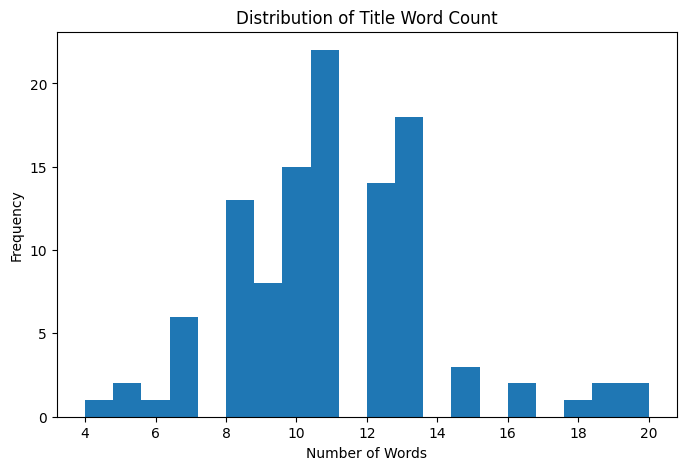

In [42]:
plt.figure(figsize=(8,5))

plt.hist(df["title_word_count"], bins=20)

plt.title("Distribution of Title Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

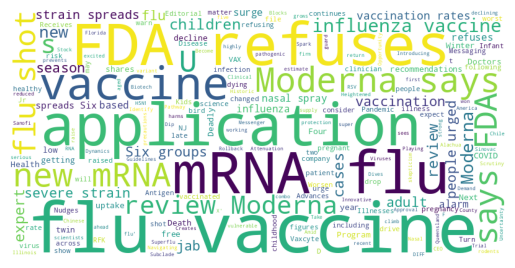

In [43]:
from wordcloud import WordCloud

text = " ".join(df["title"].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.imshow(wordcloud)
plt.axis("off")

plt.show()

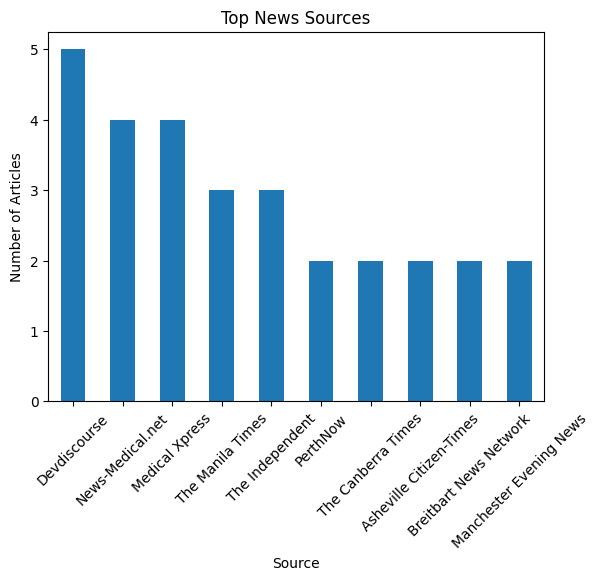

In [44]:
df['source_name'].value_counts().head(10).plot(kind="bar")

plt.title("Top News Sources")
plt.xlabel("Source")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.show()

In [45]:
df["article_length"] = df["text_full"].astype(str).apply(len)
df["article_length"].head()

,article_length
0,449
1,516
2,478
3,475
4,466


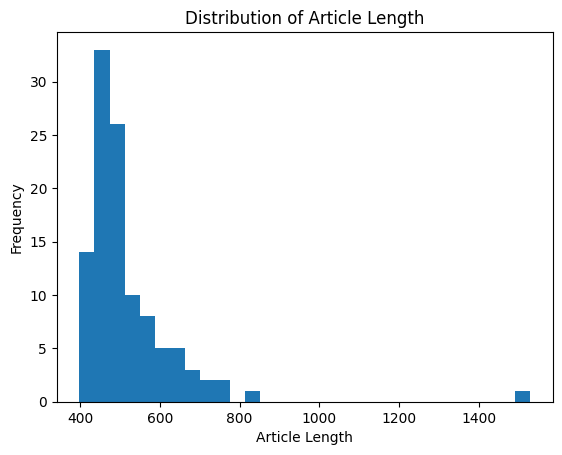

In [46]:
plt.hist(df["article_length"], bins=30)

plt.title("Distribution of Article Length")
plt.xlabel("Article Length")
plt.ylabel("Frequency")

plt.show()

In [47]:
df["publishedAt"] = pd.to_datetime(df["publishedAt"])

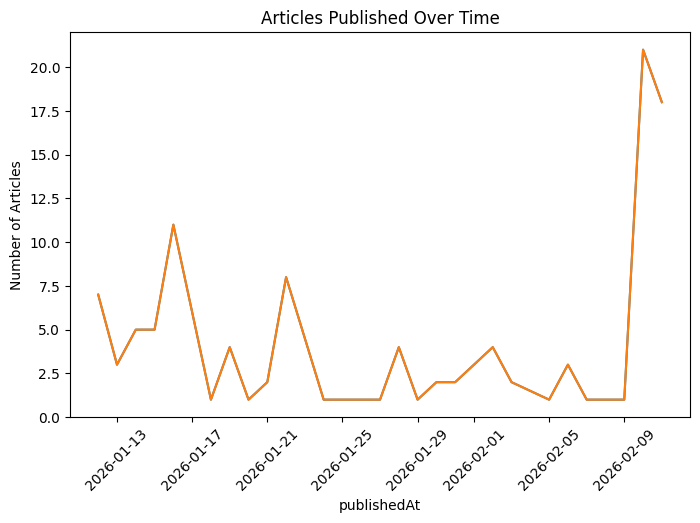

In [48]:
articles_per_day = df.groupby(df["publishedAt"].dt.date).size()

articles_per_day.plot()

plt.title("Articles Published Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
articles_per_day.plot(kind="line", figsize=(8,5))
plt.xticks(rotation=45)

plt.show()

In [49]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter

words = " ".join(df["title"].astype(str)).lower().split()

custom_stopwords = {"says", "said", "new"}

filtered_words = [
    word for word in words
    if word not in ENGLISH_STOP_WORDS
    and word not in custom_stopwords
    and len(word) > 2
]

common_words = Counter(filtered_words).most_common(10)

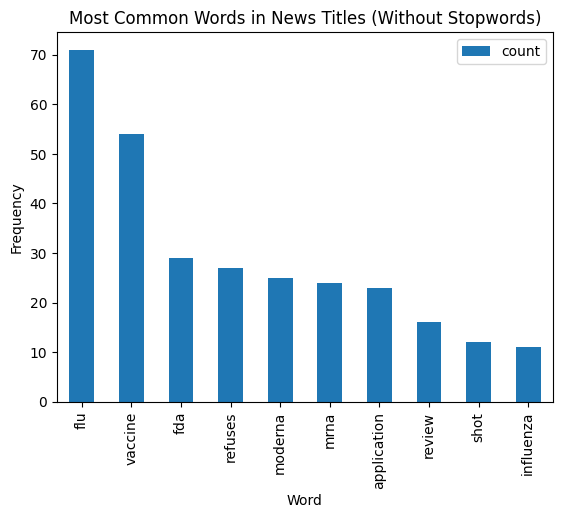

In [50]:
words_df = pd.DataFrame(common_words, columns=["word", "count"])

words_df.plot(kind="bar", x="word", y="count")

plt.title("Most Common Words in News Titles (Without Stopwords)")
plt.xlabel("Word")
plt.ylabel("Frequency")

plt.show()

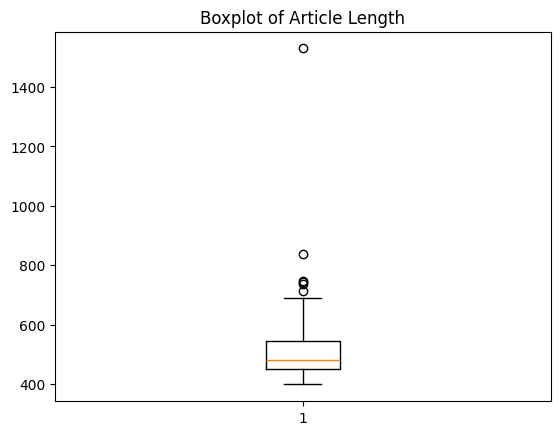

In [51]:
plt.boxplot(df["article_length"])
plt.title("Boxplot of Article Length")
plt.show()